In [ ]:
# Mount google drive

from google.colab import drive
drive.mount('/content/gdrive/',force_remount=True)

Mounted at /content/gdrive/


In [ ]:
# Right click on the BANA6350>Data folder and copy the folder path by click "Copy Path". Then paste that inside the code below to link your folder where all the data will reside

import os

path = "/content/gdrive/MyDrive/BANA6350/Data"

os.chdir(path)

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams['lines.linewidth'] = 3
plt.rcParams['figure.figsize'] = [14.0, 6.0]
plt.rcParams['font.size']= 18
plt.style.available   # Check what styles are available for Chart formats by visiting : https://matplotlib.org/stable/gallery/style_sheets/style_sheets_reference.html
plt.style.use('fivethirtyeight')       # Assigning the FiveThirtyEight format, you can choose any of the names from the above link

In [ ]:
# if for some reason your sns plots are not visible, run this  line of code in Colab
%matplotlib inline

# Imports

In [ ]:
!pip install sktime
!pip install dmba
!pip install prince
!pip install plotly
!pip install yellowbrick

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.5/149.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 72.3 MB/s eta 0:00:00


In [ ]:
# --- Core Python Libraries ---
import math
from pathlib import Path
from collections import defaultdict
import random

# --- Data Manipulation & Analysis ---
import pandas as pd
import numpy as np

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm

# --- Machine Learning (Scikit-learn) ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
    roc_curve,
    roc_auc_score,
    classification_report,
)

# --- Statsmodels  ---
import statsmodels.api as sm
import statsmodels.formula.api as smf

# --- Visualizations for Trees or Model Summaries ---
from dmba import plotDecisionTree, textDecisionTree, stepwise_selection, AIC_score
from graphviz import Digraph  # optional for visualizing decision trees
from xgboost import XGBClassifier  # optional if you choose to compare XGBoost

# --- Plot Settings ---
sns.set(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (8, 5)


Colab environment detected.


In [ ]:
# Import Dataset
heart_df = pd.read_csv("heart_cleveland_upload.csv")
heart_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [ ]:
heart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB


# EDA

In [ ]:
# Make sure visualizations look clean
sns.set(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (8, 5)

In [ ]:
heart_df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,2.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,0.602694,0.676768,0.835017,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,0.956690,0.499340
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,0.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,2.000000,1.000000


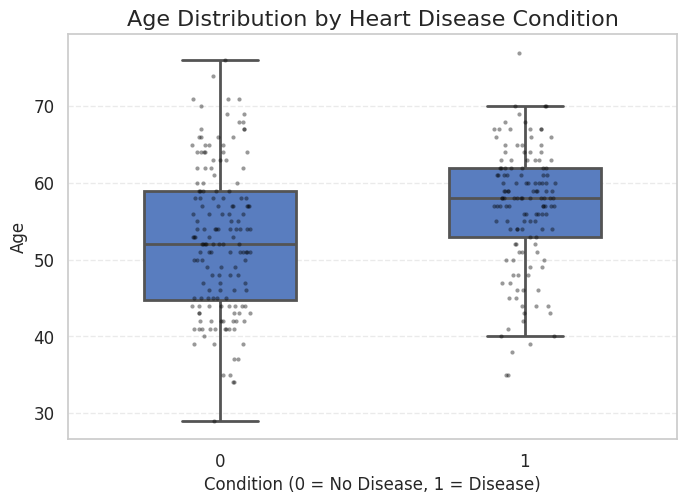

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.boxplot(
    x='condition',
    y='age',
    data=heart_df,
    linewidth=2,
    width=0.5,
    showfliers=False
)

sns.stripplot(
    x='condition',
    y='age',
    data=heart_df,
    color='black',
    size=3,
    alpha=0.4
)

plt.title("Age Distribution by Heart Disease Condition", fontsize=16)
plt.xlabel("Condition (0 = No Disease, 1 = Disease)", fontsize=12)
plt.ylabel("Age", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()


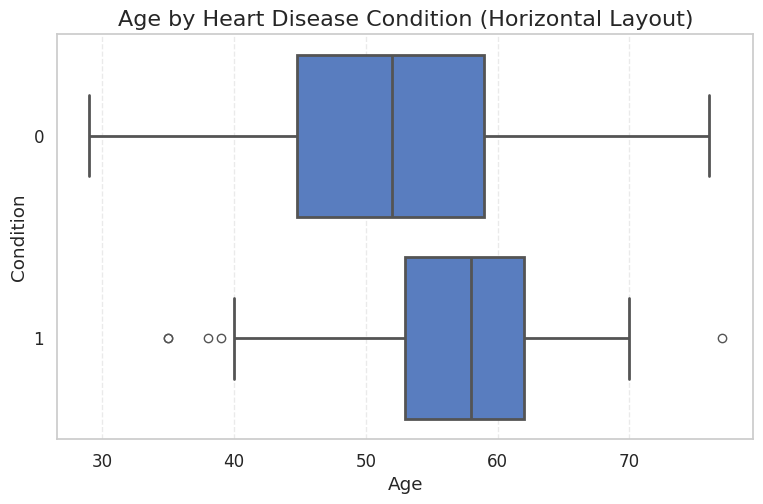

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=heart_df,
    x='age',
    y='condition',
    orient='h',
    linewidth=2
)

plt.title("Age by Heart Disease Condition (Horizontal Layout)", fontsize=16)
plt.xlabel("Age")
plt.ylabel("Condition")
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.show()


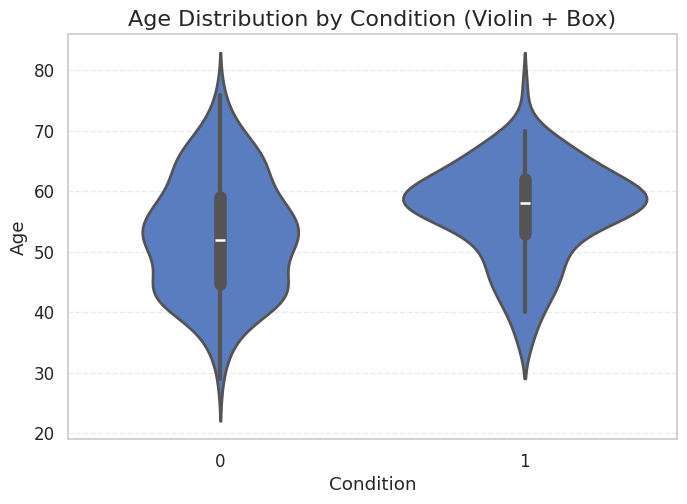

In [ ]:
plt.figure(figsize=(7,5))
sns.violinplot(
    x='condition',
    y='age',
    data=heart_df,
    inner='box',
    linewidth=2
)

plt.title("Age Distribution by Condition (Violin + Box)", fontsize=16)
plt.xlabel("Condition")
plt.ylabel("Age")
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()


/tmp/ipython-input-3367098086.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=heart_df, x='condition', palette='Set2')


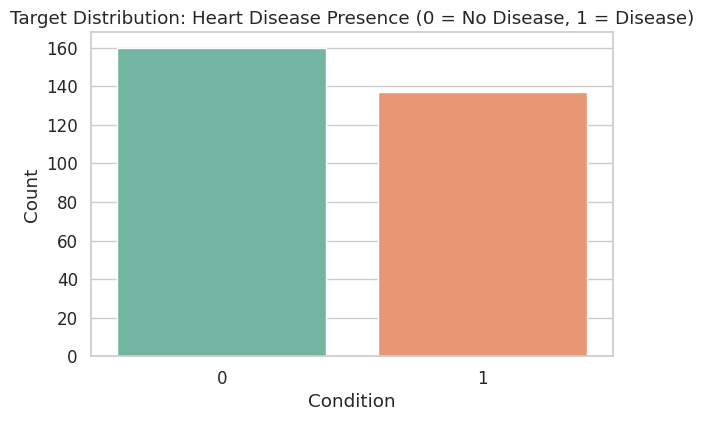

condition
0    53.87
1    46.13
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=heart_df, x='condition', palette='Set2')
plt.title('Target Distribution: Heart Disease Presence (0 = No Disease, 1 = Disease)')
plt.xlabel('Condition')
plt.ylabel('Count')
plt.show()

# Print percentage breakdown
disease_counts = heart_df['condition'].value_counts(normalize=True) * 100
print(disease_counts.round(2))


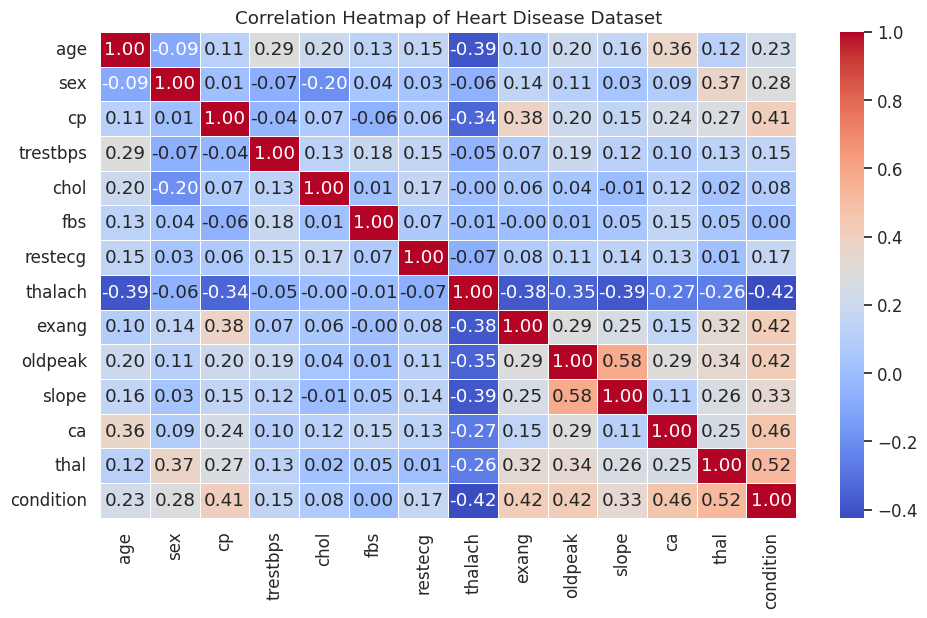

Correlation of features with target variable (condition):
condition    1.000000
thal         0.520516
ca           0.463189
oldpeak      0.424052
exang        0.421355
cp           0.408945
slope        0.333049
sex          0.278467
age          0.227075
restecg      0.166343
trestbps     0.153490
chol         0.080285
fbs          0.003167
thalach     -0.423817
Name: condition, dtype: float64


In [ ]:
plt.figure(figsize=(10,6))
corr_matrix = heart_df.corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Heart Disease Dataset")
plt.show()

# correlation with target variable
corr_with_target = corr_matrix['condition'].sort_values(ascending=False)
print("Correlation of features with target variable (condition):")
print(corr_with_target)


/tmp/ipython-input-1916966004.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


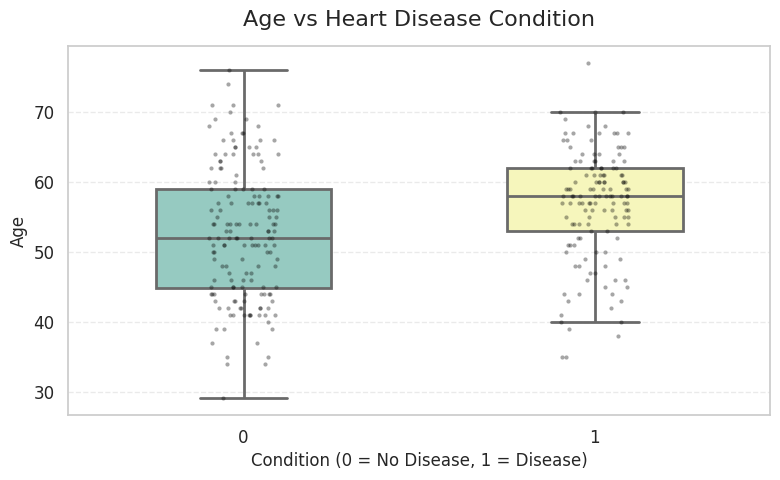

/tmp/ipython-input-1916966004.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


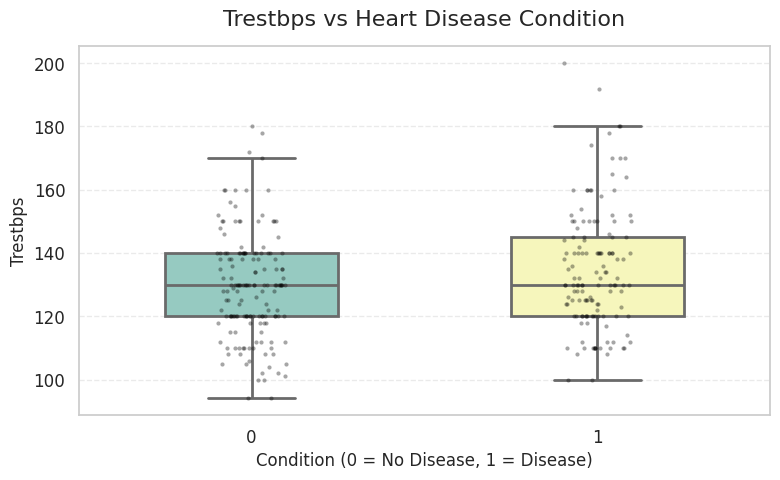

/tmp/ipython-input-1916966004.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


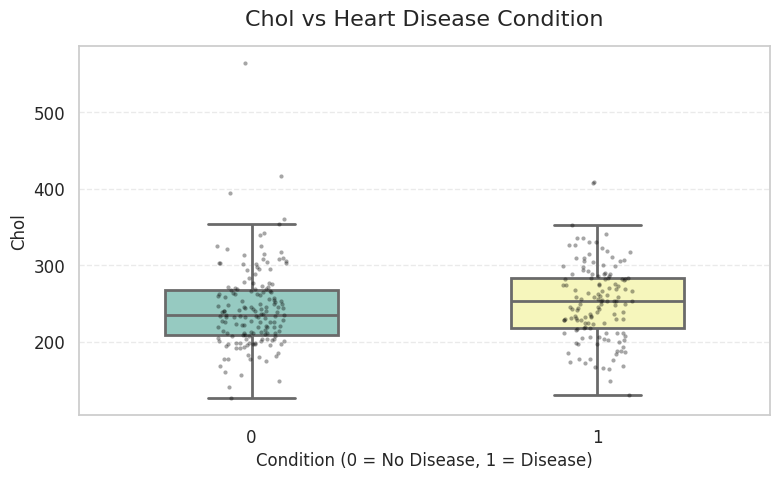

/tmp/ipython-input-1916966004.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


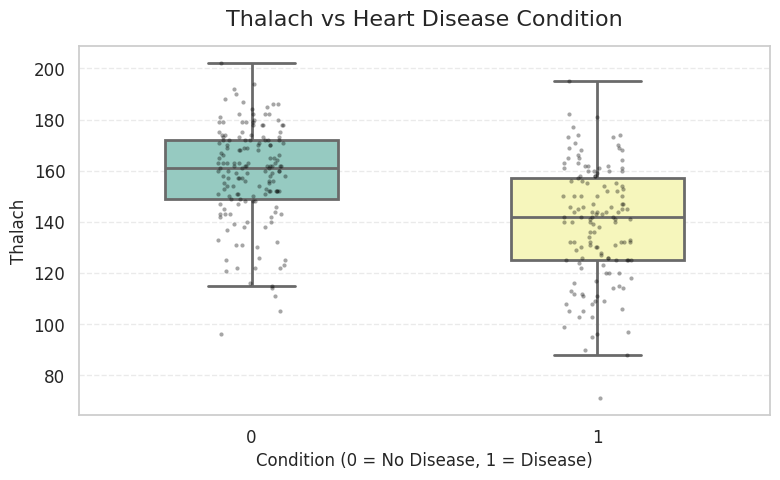

/tmp/ipython-input-1916966004.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


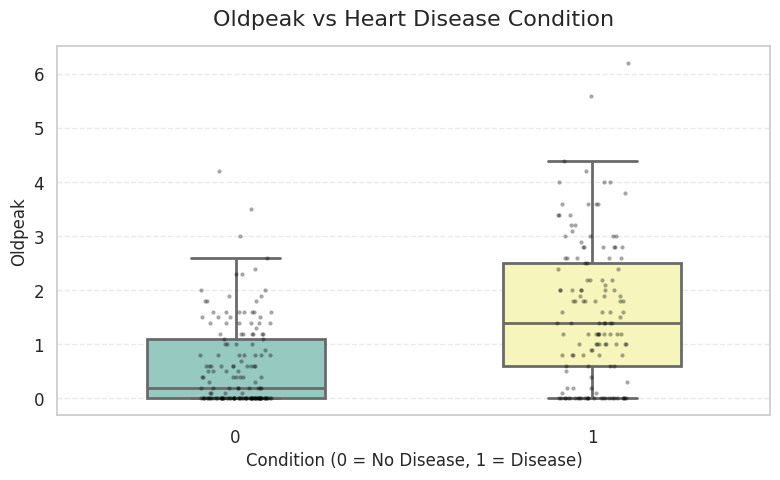

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

for col in continuous_features:
    plt.figure(figsize=(8,5))

    # Base boxplot
    sns.boxplot(
        x='condition',
        y=col,
        data=heart_df,
        showfliers=False,
        width=0.5,
        linewidth=2,
        palette='Set3'
    )

    # Add jittered points for detail
    sns.stripplot(
        x='condition',
        y=col,
        data=heart_df,
        color='black',
        size=3,
        jitter=True,
        alpha=0.35
    )

    plt.title(f'{col.capitalize()} vs Heart Disease Condition', fontsize=16, pad=15)
    plt.xlabel('Condition (0 = No Disease, 1 = Disease)', fontsize=12)
    plt.ylabel(col.capitalize(), fontsize=12)

    # Subtle grid for readability
    plt.grid(axis='y', linestyle='--', alpha=0.4)

    # Slight y-axis padding
    plt.tight_layout()

    plt.show()


# Test-Train Split

In [ ]:
# Encode categorical variables
heart_df = pd.get_dummies(heart_df, drop_first=True)

# Split
features = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
            'restecg', 'thalach', 'exang', 'oldpeak',
            'slope', 'ca', 'thal']

X = heart_df[features]# predictors
y = heart_df['condition'] # target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Logistic Regression

[[37 11]
 [ 8 34]]
              precision    recall  f1-score   support

           0       0.82      0.77      0.80        48
           1       0.76      0.81      0.78        42

    accuracy                           0.79        90
   macro avg       0.79      0.79      0.79        90
weighted avg       0.79      0.79      0.79        90

Accuracy: 0.7888888888888889
AUC: 0.7901785714285715


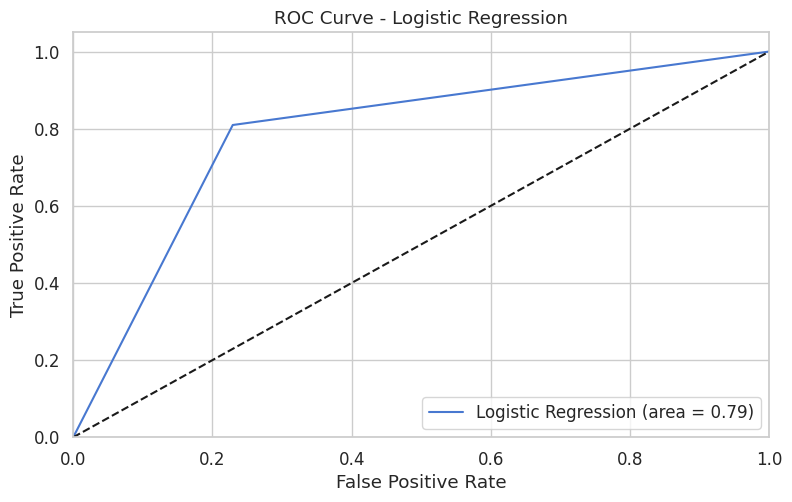

In [ ]:
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)


####################################
# Logistic Regression Results
####################################

print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("AUC:", roc_auc_score(y_test, y_pred_log))

####################################
# ROC Curve Construction
####################################
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_pred_log)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# odds ratio
import statsmodels.api as sm

X_const = sm.add_constant(X_train_scaled)
logit_model = sm.Logit(y_train, X_const)
result = logit_model.fit()

# Odds ratios
odds_ratios = pd.DataFrame({
    "Feature": features,
    "Odds Ratio": np.exp(result.params[1:])  # skip the constant
})

print(result.summary())
odds_ratios


Optimization terminated successfully.
         Current function value: 0.310901
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:              condition   No. Observations:                  207
Model:                          Logit   Df Residuals:                      193
Method:                           MLE   Df Model:                           13
Date:                Sat, 15 Nov 2025   Pseudo R-squ.:                  0.5493
Time:                        10:37:12   Log-Likelihood:                -64.356
converged:                       True   LL-Null:                       -142.78
Covariance Type:            nonrobust   LLR p-value:                 8.539e-27
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0224      0.244     -0.092      0.927      -0.501       0.457
x1            -0.1499      0.

,Feature,Odds Ratio
x1,age,0.860774
x2,sex,2.616220
x3,cp,1.332407
x4,trestbps,1.858314
x5,chol,1.628184
x6,fbs,0.584529
x7,restecg,1.288691
x8,thalach,0.477278
x9,exang,1.307144
x10,oldpeak,1.697574


# K-NN Classification

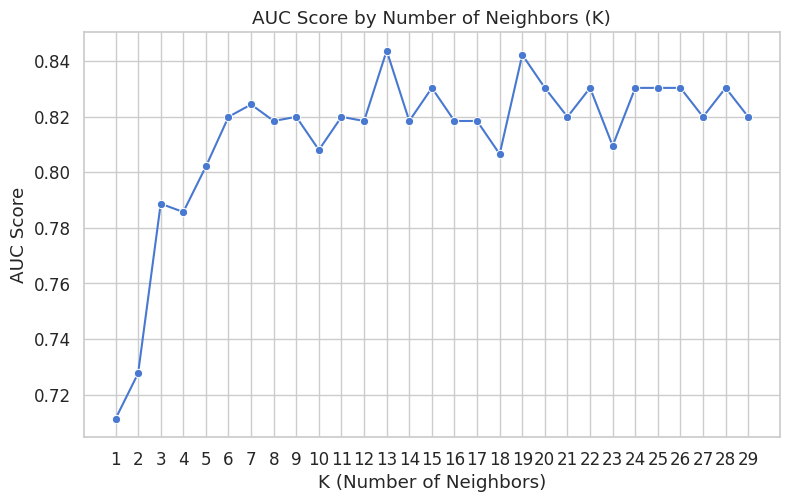

K with highest AUC: 13
Highest AUC score: 0.84375


In [ ]:
# finding the best k
auc_scores = []
k_nums = 30
for i in range(1,k_nums):
  #print("K = ", i)
  knn = KNeighborsClassifier(n_neighbors=i)
  knn.fit(X_train_scaled, y_train)
  y_pred_knn = knn.predict(X_test_scaled)
  #print(confusion_matrix(y_test, y_pred_knn))
  #print(classification_report(y_test, y_pred_knn))
  aucscore = roc_auc_score(y_test, y_pred_knn)
  auc_scores.append(aucscore)
  #print("AUC:", aucscore)
  #print()

# Plot AUC vs K
x = np.array([i for i in range(1,k_nums)])
y = np.array(auc_scores)
sns.lineplot(x=x, y=y, marker='o')

# Add title and labels
plt.title("AUC Score by Number of Neighbors (K)")
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("AUC Score")
plt.xticks(x)
plt.grid(True)
plt.show()

# Display the plot
plt.show()

# Get index of highest value (starting count at 1)
max_index = auc_scores.index(max(auc_scores)) + 1

print("K with highest AUC:", max_index)
print("Highest AUC score:", max(auc_scores))


[[41  7]
 [ 7 35]]
              precision    recall  f1-score   support

           0       0.85      0.85      0.85        48
           1       0.83      0.83      0.83        42

    accuracy                           0.84        90
   macro avg       0.84      0.84      0.84        90
weighted avg       0.84      0.84      0.84        90

Accuracy: 0.8444444444444444
AUC: 0.84375


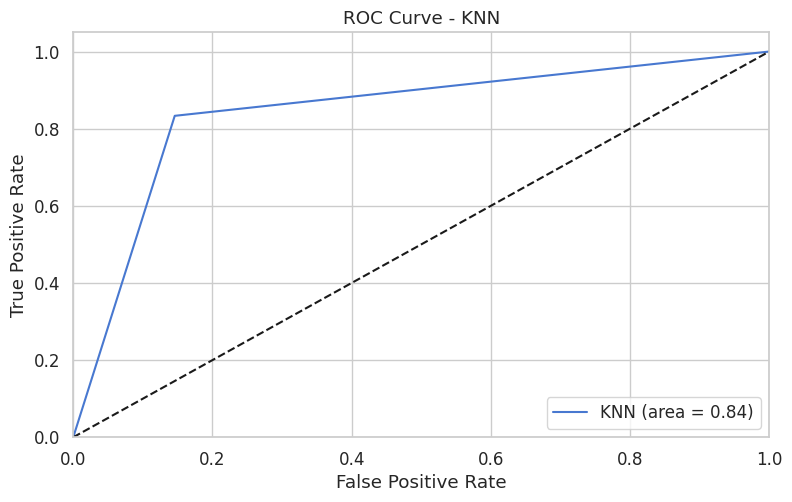

In [ ]:
# picked number of N that yields best accuracy
knn = KNeighborsClassifier(n_neighbors=13)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)


####################################
# KNN Results
####################################

print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("AUC:", roc_auc_score(y_test, y_pred_knn))


####################################
# ROC Curve Construction
####################################
fpr, tpr, thresholds = roc_curve(y_test, y_pred_knn)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label='KNN (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - KNN')
plt.legend(loc="lower right")
plt.show()

# Random Forest

[[41  7]
 [ 8 34]]
              precision    recall  f1-score   support

           0       0.84      0.85      0.85        48
           1       0.83      0.81      0.82        42

    accuracy                           0.83        90
   macro avg       0.83      0.83      0.83        90
weighted avg       0.83      0.83      0.83        90

Accuracy: 0.8333333333333334
AUC: 0.831845238095238


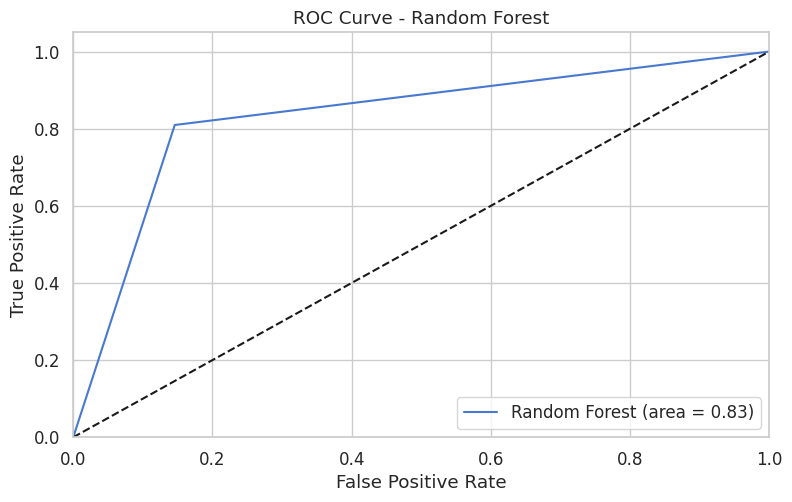

In [ ]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)



####################################
# Random Forest Results
####################################

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("AUC:", roc_auc_score(y_test, y_pred_rf))

####################################
# ROC Curve Construction
####################################
fpr, tpr, thresholds = roc_curve(y_test, y_pred_rf)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label='Random Forest (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc="lower right")
plt.show()


     Feature  Importance
7    thalach    0.139384
12      thal    0.138764
9    oldpeak    0.121444
11        ca    0.106141
3   trestbps    0.086747
0        age    0.086652
2         cp    0.083946
4       chol    0.083492
1        sex    0.045294
8      exang    0.039260
10     slope    0.036067
6    restecg    0.019670
5        fbs    0.013141


/tmp/ipython-input-3431042501.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


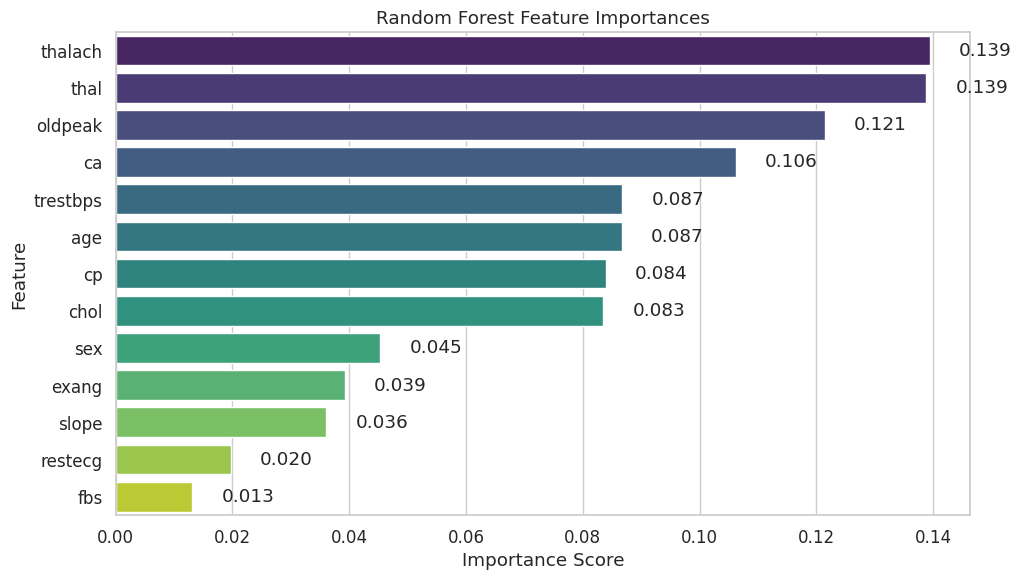

In [ ]:
####################################
# Random Forest Feature Importance (with Data Labels)
####################################

importances = rf.feature_importances_
feature_names = X.columns

# Create DataFrame
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_imp_df)

# Plot with labels
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x='Importance',
    y='Feature',
    data=feat_imp_df,
    palette='viridis'
)

plt.title('Random Forest Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()

# --- Add Data Labels ---
for i, value in enumerate(feat_imp_df['Importance']):
    plt.text(
        x=value + 0.005,     # small offset to the right of bar
        y=i,                 # matches bar position
        s=f"{value:.3f}",    # format label to 3 decimals
        va='center'
    )

plt.show()


# XGBoost

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [10:37:24] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[[39  9]
 [ 9 33]]
              precision    recall  f1-score   support

           0       0.81      0.81      0.81        48
           1       0.79      0.79      0.79        42

    accuracy                           0.80        90
   macro avg       0.80      0.80      0.80        90
weighted avg       0.80      0.80      0.80        90

Accuracy: 0.8
AUC: 0.7991071428571428


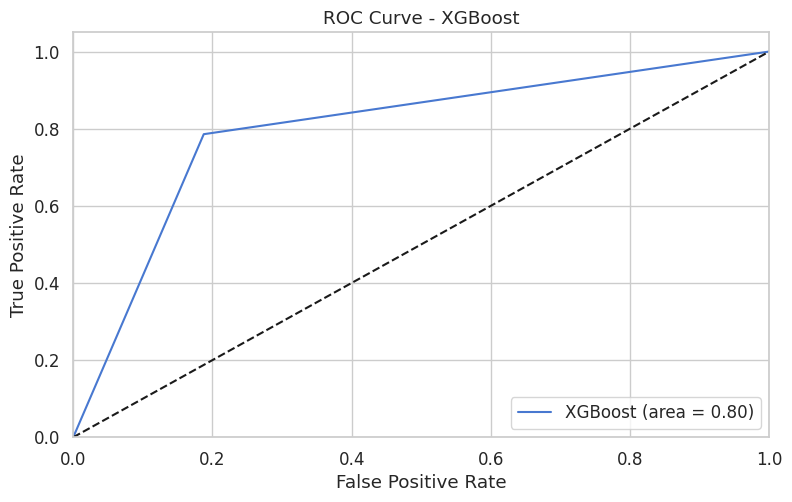

In [ ]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)



####################################
# XGBoost Results
####################################

print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("AUC:", roc_auc_score(y_test, y_pred_xgb))

####################################
# ROC Curve Construction
####################################
fpr, tpr, thresholds = roc_curve(y_test, y_pred_xgb)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label='XGBoost (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend(loc="lower right")
plt.show()


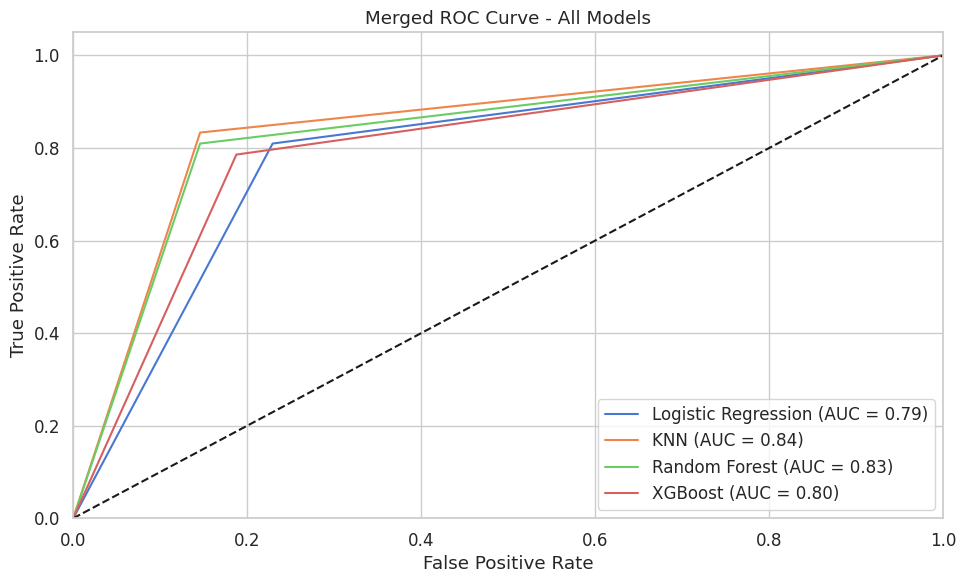

In [ ]:
####################################
# Combined ROC Curve - All Models
####################################

from sklearn.metrics import roc_curve, auc

# Compute ROC values for each model
fpr_log, tpr_log, _ = roc_curve(y_test, y_pred_log)
auc_log = auc(fpr_log, tpr_log)

fpr_knn, tpr_knn, _ = roc_curve(y_test, y_pred_knn)
auc_knn = auc(fpr_knn, tpr_knn)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_rf)
auc_rf = auc(fpr_rf, tpr_rf)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_xgb)
auc_xgb = auc(fpr_xgb, tpr_xgb)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(fpr_log, tpr_log, label='Logistic Regression (AUC = %0.2f)' % auc_log)
plt.plot(fpr_knn, tpr_knn, label='KNN (AUC = %0.2f)' % auc_knn)
plt.plot(fpr_rf, tpr_rf, label='Random Forest (AUC = %0.2f)' % auc_rf)
plt.plot(fpr_xgb, tpr_xgb, label='XGBoost (AUC = %0.2f)' % auc_xgb)

# Diagonal line
plt.plot([0,1], [0,1], 'k--')

# Labels
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Merged ROC Curve - All Models')
plt.legend(loc='lower right')
plt.show()
